<a href="https://colab.research.google.com/github/christianyesashimwe3-netizen/magna-clean-cooking-financial-model/blob/main/Clean_Cooking_Financial_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MAGNA CLEAN COOKING PROJECT

## Phase II Financial Feasibility & Scale-Up Model

**Model Type:** Driver-Based Financial Model with Scenario & Sensitivity Analysis
**Project Phase:** Phase II Pilot – Financial Feasibility and Business Model Validation
**Prepared by:** Christian Yesashimwe
**Date:** March 2026

### Project Description

The Magna Clean Cooking Project is piloting a battery-powered electric cooking service designed to provide households with reliable and affordable access to modern clean cooking without requiring them to purchase the full cooking and energy system upfront. The solution combines electric cookstoves, rechargeable battery storage, charging infrastructure, and an Energy-as-a-Service delivery model.

Following the initial technology and operational pilot, Phase II focuses on testing the project at a larger household scale and determining whether the service can transition from a pilot into a financially sustainable and scalable clean cooking business.

### Purpose of the Financial Model

This model is an internal management and decision-support tool developed to evaluate the **financial feasibility, unit economics, capital requirements, and scale-up potential** of the Magna clean cooking service during Phase II.

The foundational question guiding the model is:

**Can Magna deliver reliable battery-powered electric cooking at a price households are willing and able to pay, while generating sufficient cash flow to recover investment, sustain operations, and scale the service?**

The model translates key operational drivers—including the number of households served, customer activity and retention, pricing, electricity consumption, battery and cookstove costs, operating expenses, and potential carbon revenues—into projected financial performance.

### Key Objectives

The model is designed to:

* Determine the **true monthly cost and revenue of serving each household** and assess household-level unit economics.
* Identify the **minimum number of households required to reach operating break-even**.
* Estimate the **capital required to deploy batteries, cookstoves, and supporting infrastructure at different scales**.
* Determine **when the initial investment can be fully recovered** under different deployment and pricing assumptions.
* Compare alternative asset strategies, particularly **Battery-as-a-Service (BaaS) versus direct battery ownership**.
* Assess the potential contribution of **carbon credit revenue** while separately testing whether the core business can remain viable without relying on carbon income.
* Evaluate financial performance through **cash flow, payback period, NPV, IRR, contribution margins, and cumulative profitability**.
* Conduct **scenario and sensitivity analysis** to understand how changes in household scale, pricing, utilization, capital costs, operating costs, battery life, and other key assumptions affect financial viability.

How to interpret the model: Results are projections based on current Phase II assumptions and should not be interpreted as guaranteed financial outcomes. Pilot data should progressively replace assumptions as evidence becomes available.




**How to Use This Model**

This model is designed to assess the financial feasibility and scale-up potential of the Magna Clean Cooking Project. Users should:

**ONLY** Review and update the input assumptions based on the latest project and Phase II pilot data.

In Google Colab, select Runtime → Run all to execute the complete model.

Review the generated financial projections, break-even analysis, sensitivity tables, and plots for the BaaS and Battery Ownership scenarios.

Use the results to test how changes in pricing, household scale, operating costs, battery costs, and other key assumptions affect financial viability.

Note: The model is a working decision-support tool. Current results are preliminary and should be updated as actual Phase II operational and financial data become available.

In [51]:
from __future__ import annotations

from dataclasses import dataclass, asdict
from typing import Dict, List, Tuple
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [52]:
# =========================
# 1) CONFIG / INPUTS
# =========================

@dataclass
class ModelInputs:
    # -------------------------------------
    # Scenario B: Battery ownership
    # -------------------------------------
    # Time horizon
    start_year: int = 2026
    months: int = 60  # internal mgmt horizon

    # Deployment plan (cumulative households by month index)
    # Q1 -> 30, Q2 -> 60, Q3 -> 90, then hold flat
    # can be changed this to any ramp.
    deployment_targets: Dict[int, int] = None  # month_index (1..months) -> total enrolled HH

    # Activity / adoption
    active_rate: float = 0.85  # % of enrolled HH active in a month
    churn_rate_monthly: float = 0.01  # fraction of enrolled HH that churn each month (optional)
    new_enroll_replace_churn: bool = True

    # Cooking / energy
    kwh_per_meal: float = 0.8
    meals_per_day: float = 2.0
    charging_loss: float = 0.10  # 10% loss (more kWh must be purchase than delivered)

    # Battery service (outsourced)
    allocated_storage_kwh_per_hh: float = 5.0  # "available storage" paid for per HH
    baas_usd_per_kwh_month: float = 2.0
    usd_to_rwf: float = 1300.0

    # -------------------------------------
    # Scenario B: Battery ownership
    # -------------------------------------

    battery_purchase_cost_usd: float = 300.0
    cookstove_purchase_cost_usd: float = 60.0

    # Customer monthly payment under ownership scenario
    ownership_monthly_fee_usd_per_hh: float = 11.0

    # Total monthly project operating cost
    ownership_monthly_operating_cost_usd: float = 1300.0

    # Long-term investment analysis horizon
    ownership_analysis_months: int = 60  # 5 years

    # Optional residual value after 5 years
    battery_residual_value_pct: float = 0.0

    # Pricing / sales
    price_per_charge_rwf: float = 1500.0
    charges_per_week_per_active_hh: float = 3.0  # average realized charges
    weeks_per_month: float = 4.3

    # Electricity / charging costs
    electricity_tariff_rwf_per_kwh: float = 150.0

    # Variable costs
    mobile_money_fee_pct: float = 0.02  # % of revenue
    maintenance_rwf_per_active_hh_month: float = 100.0  # stove repairs, minor ops
    field_ops_variable_rwf_per_active_hh_month: float = 300.0  # e.g., consumables, small logistics

    # Fixed costs (monthly)
    fixed_staff_rwf: float = 1_000_000.0
    fixed_transport_rwf: float = 100_000.0
    fixed_rent_storage_rwf: float = 50_000.0
    fixed_monitoring_data_rwf: float = 20_000.0
    fixed_admin_misc_rwf: float = 100_000.0

    # Optional carbon revenue (kept separate to see viability without it)
    include_carbon: bool = False
    tco2_avoided_per_hh_year: float = 1.5
    carbon_price_usd_per_t: float = 12.0
    carbon_verification_fee_pct: float = 0.15  # share of carbon revenue lost to MRV/fees

    # Basic finance / evaluation
    discount_rate_annual: float = 0.15  # for NPV, if you want
    show_debug: bool = False


def default_deployment_targets(months: int) -> Dict[int, int]:
    """
    Cumulative enrolled households by month (1-indexed).
    Q1 months 1-3 -> 30
    Q2 months 4-6 -> 60
    Q3 months 7-9 -> 90
    months 10+ -> 90
    """
    targets = {}
    for m in range(1, months + 1):
        if m <= 3:
            targets[m] = 30
        elif m <= 6:
            targets[m] = 60
        elif m <= 9:
            targets[m] = 90
        else:
            targets[m] = 90
    return targets

In [53]:
# =========================
# 2) CORE CALCS
# =========================

def monthly_kwh_delivered_per_active_hh(inp: ModelInputs) -> float:
    daily = inp.kwh_per_meal * inp.meals_per_day
    return daily * 30.0  # approximation


def monthly_kwh_purchased_per_active_hh(inp: ModelInputs) -> float:
    delivered = monthly_kwh_delivered_per_active_hh(inp)
    # purchased = delivered / (1 - loss)
    return delivered / (1.0 - inp.charging_loss)


def monthly_revenue_per_active_hh(inp: ModelInputs) -> float:
    return inp.price_per_charge_rwf * inp.charges_per_week_per_active_hh * inp.weeks_per_month


def battery_baas_cost_per_enrolled_hh_month(inp: ModelInputs) -> float:
    # pay based on "available storage" regardless of usage
    return inp.allocated_storage_kwh_per_hh * inp.baas_usd_per_kwh_month * inp.usd_to_rwf


def carbon_revenue_per_enrolled_hh_month(inp: ModelInputs) -> float:
    # Annual to monthly, net of verification fee
    gross_usd_year = inp.tco2_avoided_per_hh_year * inp.carbon_price_usd_per_t
    net_usd_year = gross_usd_year * (1.0 - inp.carbon_verification_fee_pct)
    net_rwf_month = (net_usd_year * inp.usd_to_rwf) / 12.0
    return net_rwf_month


def build_month_index(inp: ModelInputs) -> pd.DataFrame:
    # month index and labels
    rows = []
    y = inp.start_year
    month = 1
    for i in range(1, inp.months + 1):
        rows.append({"month_index": i, "year": y, "month": month})
        month += 1
        if month == 13:
            month = 1
            y += 1
    return pd.DataFrame(rows)


def simulate(inp: ModelInputs) -> pd.DataFrame:
    if inp.deployment_targets is None:
        inp.deployment_targets = default_deployment_targets(inp.months)

    df = build_month_index(inp)

    # Deployment logic: enrolled HH target by month
    df["enrolled_hh_target"] = df["month_index"].map(inp.deployment_targets).fillna(method="ffill").astype(int)

    # Model churn on enrolled base (optional)
    enrolled = 0.0
    enrolled_list = []
    new_enroll_list = []
    churn_list = []

    for _, row in df.iterrows():
        target = float(row["enrolled_hh_target"])

        # churn on current enrolled
        churn = enrolled * inp.churn_rate_monthly
        enrolled_after_churn = max(0.0, enrolled - churn)

        # new enrollments to reach target
        if inp.new_enroll_replace_churn:
            new_enroll = max(0.0, target - enrolled_after_churn)
            enrolled = enrolled_after_churn + new_enroll
        else:
            # enrollment is driven only by increases in target
            new_enroll = max(0.0, target - enrolled)
            enrolled = enrolled + new_enroll
            # then churn already applied; enrolled is "pre-churn + new":
            enrolled = enrolled_after_churn + new_enroll

        # cap at target (to avoid overshoot due to rounding)
        enrolled = min(enrolled, target)

        enrolled_list.append(enrolled)
        new_enroll_list.append(new_enroll)
        churn_list.append(churn)

    df["enrolled_hh"] = pd.Series(enrolled_list).round(0).astype(int)
    df["new_enrollments"] = pd.Series(new_enroll_list).round(0).astype(int)
    df["churned_hh"] = pd.Series(churn_list).round(0).astype(int)

    # Active households
    df["active_hh"] = (df["enrolled_hh"] * inp.active_rate).round(0).astype(int)

    # Usage & revenue
    rev_per_active = monthly_revenue_per_active_hh(inp)
    df["revenue_rwf"] = df["active_hh"] * rev_per_active

    # Energy
    kwh_purchased_per_active = monthly_kwh_purchased_per_active_hh(inp)
    df["kwh_purchased"] = df["active_hh"] * kwh_purchased_per_active
    df["electricity_cost_rwf"] = df["kwh_purchased"] * inp.electricity_tariff_rwf_per_kwh

    # Battery BaaS (based on enrolled HH, not active)
    baas_per_enrolled = battery_baas_cost_per_enrolled_hh_month(inp)
    df["battery_baas_cost_rwf"] = df["enrolled_hh"] * baas_per_enrolled

    # Other variable costs
    df["mobile_money_fees_rwf"] = df["revenue_rwf"] * inp.mobile_money_fee_pct
    df["maintenance_rwf"] = df["active_hh"] * inp.maintenance_rwf_per_active_hh_month
    df["field_ops_variable_rwf"] = df["active_hh"] * inp.field_ops_variable_rwf_per_active_hh_month

    df["variable_costs_rwf"] = (
        df["electricity_cost_rwf"]
        + df["battery_baas_cost_rwf"]
        + df["mobile_money_fees_rwf"]
        + df["maintenance_rwf"]
        + df["field_ops_variable_rwf"]
    )

    # Fixed costs
    df["fixed_costs_rwf"] = (
        inp.fixed_staff_rwf
        + inp.fixed_transport_rwf
        + inp.fixed_rent_storage_rwf
        + inp.fixed_monitoring_data_rwf
        + inp.fixed_admin_misc_rwf
    )

    # Optional carbon
    if inp.include_carbon:
        carbon_per_enrolled = carbon_revenue_per_enrolled_hh_month(inp)
        df["carbon_revenue_rwf"] = df["enrolled_hh"] * carbon_per_enrolled
    else:
        df["carbon_revenue_rwf"] = 0.0

    # Profit metrics
    df["gross_margin_rwf"] = df["revenue_rwf"] - (df["electricity_cost_rwf"] + df["battery_baas_cost_rwf"])
    df["operating_profit_rwf"] = df["revenue_rwf"] + df["carbon_revenue_rwf"] - (df["variable_costs_rwf"] + df["fixed_costs_rwf"])

    # Unit economics
    df["rev_per_active_hh"] = df["revenue_rwf"] / df["active_hh"].replace({0: pd.NA})
    df["baas_per_enrolled_hh"] = df["battery_baas_cost_rwf"] / df["enrolled_hh"].replace({0: pd.NA})
    df["op_profit_per_enrolled_hh"] = df["operating_profit_rwf"] / df["enrolled_hh"].replace({0: pd.NA})

    # Storage utilization KPI (how much of paid-for storage is actually used)
    # paid_storage_kwh = enrolled_hh * allocated_storage_kwh_per_hh
    # delivered_kwh approximated by active_hh * delivered_per_active_hh
    delivered_per_active = monthly_kwh_delivered_per_active_hh(inp)
    df["kwh_delivered"] = df["active_hh"] * delivered_per_active
    df["paid_storage_kwh"] = df["enrolled_hh"] * inp.allocated_storage_kwh_per_hh
    # Utilization proxy: delivered_kwh / (paid_storage_kwh * 30-day turnover factor?)
    # Not perfect, but useful as an internal indicator.
    # compute: kWh delivered per month / (paid_storage_kWh * 30 * 1kWh per kWh capacity if cycled daily) -> cycle depth indicator.
    df["storage_depth_of_cycle_per_day"] = (df["kwh_delivered"] / df["paid_storage_kwh"].replace({0: pd.NA})) / 30.0

    return df


In [54]:

# =========================
# 3) BREAK-EVEN + NPV
# =========================

def break_even_active_hh(inp: ModelInputs) -> Tuple[float, float]:
    """
    Compute approximate break-even active households (monthly) ignoring churn/dynamics:
    Finding HH number allowing us an operating profit = 0.

    Solve for active_hh, but note BaaS is on enrolled_hh. approximate enrolled_hh = active_hh / active_rate.
    """
    if inp.active_rate <= 0:
        return math.inf, math.inf

    rev_per_active = monthly_revenue_per_active_hh(inp)
    kwh_purchased_per_active = monthly_kwh_purchased_per_active_hh(inp)
    elec_per_active = kwh_purchased_per_active * inp.electricity_tariff_rwf_per_kwh

    # BaaS per enrolled
    baas_per_enrolled = battery_baas_cost_per_enrolled_hh_month(inp)

    # Other variable per active
    other_var_per_active = (
        (rev_per_active * inp.mobile_money_fee_pct)
        + inp.maintenance_rwf_per_active_hh_month
        + inp.field_ops_variable_rwf_per_active_hh_month
    )

    fixed = (
        inp.fixed_staff_rwf
        + inp.fixed_transport_rwf
        + inp.fixed_rent_storage_rwf
        + inp.fixed_monitoring_data_rwf
        + inp.fixed_admin_misc_rwf
    )

    carbon_per_enrolled = carbon_revenue_per_enrolled_hh_month(inp) if inp.include_carbon else 0.0

    # Profit per active HH:
    # revenue_per_active
    # - electricity_per_active
    # - other_var_per_active
    # - (baas_per_enrolled - carbon_per_enrolled) * enrolled_per_active
    enrolled_per_active = 1.0 / inp.active_rate
    contribution_per_active = (
        rev_per_active
        - elec_per_active
        - other_var_per_active
        - (baas_per_enrolled - carbon_per_enrolled) * enrolled_per_active
    )

    if contribution_per_active <= 0:
        return math.inf, contribution_per_active

    be_active = fixed / contribution_per_active
    return be_active, contribution_per_active


def npv_of_operating_profit(df: pd.DataFrame, inp: ModelInputs) -> float:
    r = inp.discount_rate_annual
    monthly_rate = (1.0 + r) ** (1.0 / 12.0) - 1.0
    npv = 0.0
    for i, op in enumerate(df["operating_profit_rwf"].tolist(), start=1):
        npv += op / ((1.0 + monthly_rate) ** i)
    return npv

In [55]:
# =========================
# 4) SENSITIVITY
# =========================

def run_sensitivity(inp: ModelInputs, grid: Dict[str, List[float]]) -> pd.DataFrame:
    """
    grid example:
    {
      "price_per_charge_rwf": [800, 1000, 1200],
      "charges_per_week_per_active_hh": [2.5, 3.0, 3.5],
      "active_rate": [0.75, 0.85, 0.95],
      "usd_to_rwf": [1200, 1300, 1400]
    }
    """
    keys = list(grid.keys())
    results = []

    def rec(idx: int, cur: Dict[str, float]):
        if idx == len(keys):
            test = ModelInputs(**{**asdict(inp), **cur})
            df = simulate(test)
            be_active, contrib = break_even_active_hh(test)
            results.append({
                **cur,
                "total_revenue_rwf": float(df["revenue_rwf"].sum()),
                "total_op_profit_rwf": float(df["operating_profit_rwf"].sum()),
                "npv_op_profit_rwf": float(npv_of_operating_profit(df, test)),
                "break_even_active_hh": float(be_active),
                "contribution_per_active_hh": float(contrib),
            })
            return

        k = keys[idx]
        for v in grid[k]:
            cur2 = dict(cur)
            cur2[k] = v
            rec(idx + 1, cur2)

    rec(0, {})
    return pd.DataFrame(results)

In [56]:
# ============================================================
# 5) SCENARIO B — BATTERY OWNERSHIP MODEL
# ============================================================

def ownership_capex_per_hh(inp: ModelInputs) -> float:
    """
    Initial equipment investment required per household.
    """
    return (
        inp.battery_purchase_cost_usd
        + inp.cookstove_purchase_cost_usd
    )


def simulate_ownership(
    inp: ModelInputs,
    num_households: int
) -> pd.DataFrame:
    """
    Simulates the battery ownership business model for a fixed
    number of households over the ownership analysis period.

    Assumptions:
    - Magna buys batteries and cookstoves upfront.
    - Each household pays a fixed monthly service fee.
    - Project incurs a fixed monthly operating cost.
    - Initial CAPEX occurs at Month 0.
    """

    if num_households <= 0:
        raise ValueError("num_households must be greater than zero.")

    months = inp.ownership_analysis_months

    capex_per_hh = ownership_capex_per_hh(inp)

    initial_capex = (
        num_households
        * capex_per_hh
    )

    monthly_revenue = (
        num_households
        * inp.ownership_monthly_fee_usd_per_hh
    )

    monthly_operating_cost = (
        inp.ownership_monthly_operating_cost_usd
    )

    monthly_operating_cashflow = (
        monthly_revenue
        - monthly_operating_cost
    )

    rows = []

    # Month 0 = initial investment
    cumulative_cashflow = -initial_capex

    rows.append({
        "month": 0,
        "households": num_households,
        "revenue_usd": 0,
        "operating_cost_usd": 0,
        "capex_usd": initial_capex,
        "net_cashflow_usd": -initial_capex,
        "cumulative_cashflow_usd": cumulative_cashflow
    })

    # Months 1–60
    for month in range(1, months + 1):

        net_cashflow = monthly_operating_cashflow

        cumulative_cashflow += net_cashflow

        rows.append({
            "month": month,
            "households": num_households,
            "revenue_usd": monthly_revenue,
            "operating_cost_usd": monthly_operating_cost,
            "capex_usd": 0,
            "net_cashflow_usd": net_cashflow,
            "cumulative_cashflow_usd": cumulative_cashflow
        })

    df = pd.DataFrame(rows)

    return df

In [57]:
# ============================================================
# 6) OWNERSHIP FINANCIAL METRICS
# ============================================================

def ownership_metrics(
    inp: ModelInputs,
    num_households: int
) -> Dict:

    df = simulate_ownership(
        inp,
        num_households
    )

    capex_per_hh = ownership_capex_per_hh(inp)

    initial_investment = (
        num_households
        * capex_per_hh
    )

    monthly_revenue = (
        num_households
        * inp.ownership_monthly_fee_usd_per_hh
    )

    monthly_net_cashflow = (
        monthly_revenue
        - inp.ownership_monthly_operating_cost_usd
    )

    # First month cumulative cash flow becomes positive
    positive_cashflow = df[
        df["cumulative_cashflow_usd"] >= 0
    ]

    if positive_cashflow.empty:
        payback_month = None
        payback_years = None
    else:
        payback_month = int(
            positive_cashflow.iloc[0]["month"]
        )

        payback_years = (
            payback_month / 12
        )

    five_year_net_cashflow = (
        df.iloc[-1][
            "cumulative_cashflow_usd"
        ]
    )

    roi_5yr = (
        five_year_net_cashflow
        / initial_investment
        if initial_investment > 0
        else np.nan
    )

    return {
        "households": num_households,

        "capex_per_hh_usd":
            capex_per_hh,

        "initial_investment_usd":
            initial_investment,

        "monthly_revenue_usd":
            monthly_revenue,

        "monthly_operating_cost_usd":
            inp.ownership_monthly_operating_cost_usd,

        "monthly_net_cashflow_usd":
            monthly_net_cashflow,

        "payback_month":
            payback_month,

        "payback_years":
            payback_years,

        "five_year_net_cashflow_usd":
            five_year_net_cashflow,

        "five_year_roi":
            roi_5yr
    }

In [58]:
# ============================================================
# 7) OWNERSHIP BREAK-EVEN ANALYSIS
# ============================================================

def ownership_break_even(
    inp: ModelInputs
) -> Dict:

    monthly_fee = (
        inp.ownership_monthly_fee_usd_per_hh
    )

    monthly_opex = (
        inp.ownership_monthly_operating_cost_usd
    )

    capex_per_hh = (
        ownership_capex_per_hh(inp)
    )

    months = (
        inp.ownership_analysis_months
    )

    # ---------------------------------------
    # Operating break-even
    # ---------------------------------------

    operating_break_even_hh = math.ceil(
        monthly_opex
        / monthly_fee
    )

    # ---------------------------------------
    # 5-year full investment recovery
    # ---------------------------------------

    monthly_capex_recovery_per_hh = (
        capex_per_hh
        / months
    )

    contribution_after_capex_recovery = (
        monthly_fee
        - monthly_capex_recovery_per_hh
    )

    if contribution_after_capex_recovery <= 0:

        investment_recovery_break_even_hh = (
            math.inf
        )

    else:

        investment_recovery_break_even_hh = (
            math.ceil(
                monthly_opex
                / contribution_after_capex_recovery
            )
        )

    return {

        "operating_break_even_households":
            operating_break_even_hh,

        "five_year_investment_recovery_households":
            investment_recovery_break_even_hh
    }

In [59]:
# ============================================================
# 8) OWNERSHIP SENSITIVITY ANALYSIS
# ============================================================

def run_ownership_sensitivity(
    inp: ModelInputs,
    household_range=range(50, 501, 10)
) -> pd.DataFrame:

    results = []

    for households in household_range:

        metrics = ownership_metrics(
            inp,
            households
        )

        results.append(metrics)

    return pd.DataFrame(results)

In [60]:
def ownership_price_scale_sensitivity(
    inp: ModelInputs,
    household_values: List[int],
    monthly_fee_values: List[float]
) -> pd.DataFrame:

    results = []

    for fee in monthly_fee_values:

        for households in household_values:

            test_inp = ModelInputs(
                **{
                    **asdict(inp),

                    "ownership_monthly_fee_usd_per_hh":
                        fee
                }
            )

            metrics = ownership_metrics(
                test_inp,
                households
            )

            results.append({
                "monthly_fee_usd":
                    fee,

                **metrics
            })

    return pd.DataFrame(results)

In [61]:
# ============================================================
# 9) RUN MODEL — COLAB
# ============================================================

inp = ModelInputs()

inp.deployment_targets = (
    default_deployment_targets(
        inp.months
    )
)


# ------------------------------------------
# Scenario A — BaaS
# ------------------------------------------

baas_df = simulate(inp)

baas_break_even, baas_contribution = (
    break_even_active_hh(inp)
)


# ------------------------------------------
# Scenario A sensitivity
# ------------------------------------------

baas_sensitivity_grid = {

    "price_per_charge_rwf":
        [900, 1000, 1100],

    "charges_per_week_per_active_hh":
        [2.5, 3.0, 3.5],

    "active_rate":
        [0.80, 0.85, 0.90]
}

baas_sens = run_sensitivity(
    inp,
    baas_sensitivity_grid
)


# ------------------------------------------
# Scenario B — Ownership
# ------------------------------------------

ownership_sens = (
    run_ownership_sensitivity(
        inp,
        range(50, 501, 10)
    )
)


ownership_be = (
    ownership_break_even(inp)
)

/tmp/ipykernel_552/3034778279.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["enrolled_hh_target"] = df["month_index"].map(inp.deployment_targets).fillna(method="ffill").astype(int)
/tmp/ipykernel_552/3034778279.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["enrolled_hh_target"] = df["month_index"].map(inp.deployment_targets).fillna(method="ffill").astype(int)
/tmp/ipykernel_552/3034778279.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["enrolled_hh_target"] = df["month_index"].map(inp.deployment_targets).fillna(method="ffill").astype(int)
/tmp/ipykernel_552/3034778279.py:54: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill()

In [62]:
baas_df

baas_sens

ownership_sens

ownership_be

{'operating_break_even_households': 119,
 'five_year_investment_recovery_households': 260}

In [63]:
# ============================================================
# 10) TABLE OUTPUTS
# ============================================================

print(
    "\n"
    "===================================="
)

print(
    "SCENARIO B — BATTERY OWNERSHIP"
)

print(
    "===================================="
)


print(
    "\nOperating break-even:"
)

print(
    ownership_be[
        "operating_break_even_households"
    ],
    "households"
)


print(
    "\n5-year investment recovery break-even:"
)

print(
    ownership_be[
        "five_year_investment_recovery_households"
    ],
    "households"
)


SCENARIO B — BATTERY OWNERSHIP

Operating break-even:
119 households

5-year investment recovery break-even:
260 households


In [64]:
ownership_table = ownership_sens[
    [
        "households",

        "initial_investment_usd",

        "monthly_revenue_usd",

        "monthly_operating_cost_usd",

        "monthly_net_cashflow_usd",

        "payback_month",

        "payback_years",

        "five_year_net_cashflow_usd",

        "five_year_roi"
    ]
].copy()


ownership_table[
    "five_year_roi"
] = (

    ownership_table[
        "five_year_roi"
    ] * 100

)


display(
    ownership_table.round(2)
)

,households,initial_investment_usd,monthly_revenue_usd,monthly_operating_cost_usd,monthly_net_cashflow_usd,payback_month,payback_years,five_year_net_cashflow_usd,five_year_roi
0,50,18000.0,550.0,1300.0,-750.0,NaN,NaN,-63000.0,-350.00
1,60,21600.0,660.0,1300.0,-640.0,NaN,NaN,-60000.0,-277.78
2,70,25200.0,770.0,1300.0,-530.0,NaN,NaN,-57000.0,-226.19
3,80,28800.0,880.0,1300.0,-420.0,NaN,NaN,-54000.0,-187.50
4,90,32400.0,990.0,1300.0,-310.0,NaN,NaN,-51000.0,-157.41
5,100,36000.0,1100.0,1300.0,-200.0,NaN,NaN,-48000.0,-133.33
6,110,39600.0,1210.0,1300.0,-90.0,NaN,NaN,-45000.0,-113.64
7,120,43200.0,1320.0,1300.0,20.0,NaN,NaN,-42000.0,-97.22
8,130,46800.0,1430.0,1300.0,130.0,NaN,NaN,-39000.0,-83.33
9,140,50400.0,1540.0,1300.0,240.0,NaN,NaN,-36000.0,-71.43


In [65]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

def format_chart(ax, title, subtitle=None, xlabel=None, ylabel=None):

    # Remove unnecessary borders
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    # Light horizontal grid only
    ax.grid(
        axis="y",
        alpha=0.15,
        linewidth=0.8
    )

    ax.set_axisbelow(True)

    # Left-aligned title
    ax.set_title(
        title,
        loc="left",
        fontsize=16,
        fontweight="bold",
        pad=20
    )

    # Optional subtitle
    if subtitle:
        ax.text(
            0,
            1.02,
            subtitle,
            transform=ax.transAxes,
            fontsize=10,
            alpha=0.65
        )

    ax.set_xlabel(
        xlabel if xlabel else "",
        fontsize=10
    )

    ax.set_ylabel(
        ylabel if ylabel else "",
        fontsize=10
    )

    ax.tick_params(
        labelsize=9
    )

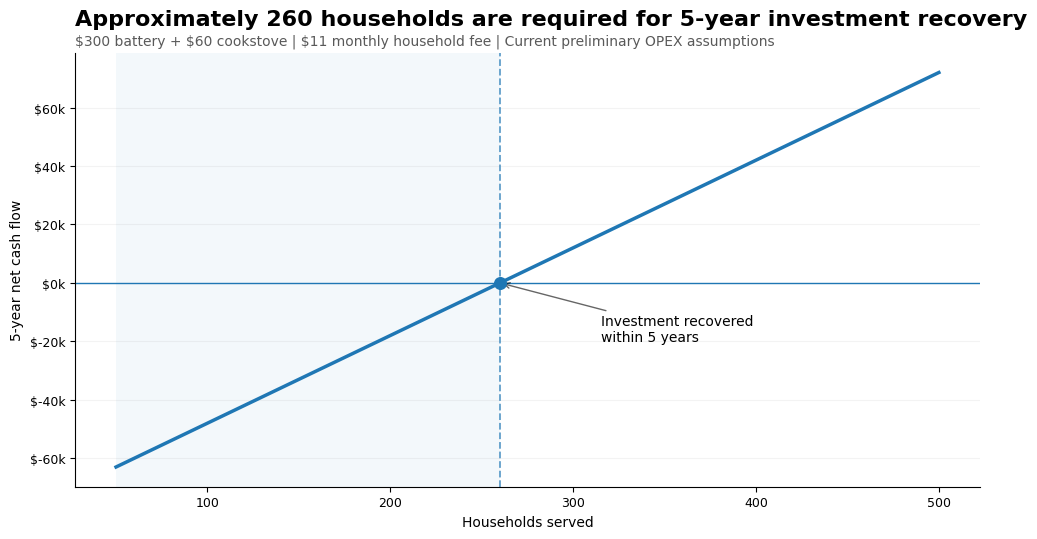

In [74]:
# ============================================================
# PLOT 1
# 5-YEAR NET CASH FLOW VS HOUSEHOLDS
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.plot(
    ownership_sens["households"],
    ownership_sens["five_year_net_cashflow_usd"],
    linewidth=2.5
)

# Zero / break-even line
ax.axhline(
    0,
    linewidth=1
)

# 260 HH threshold
ax.axvline(
    260,
    linestyle="--",
    linewidth=1.3,
    alpha=0.7
)

ax.scatter(
    260,
    0,
    s=70,
    zorder=5
)

ax.annotate(
    "Investment recovered\nwithin 5 years",
    xy=(260, 0),
    xytext=(315, -20000),
    arrowprops=dict(
        arrowstyle="->",
        alpha=0.6
    ),
    fontsize=10
)

# Shade negative zone
ax.axvspan(
    50,
    260,
    alpha=0.05
)

# Format USD axis
ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x/1000:,.0f}k"
    )
)

format_chart(
    ax,
    title="Approximately 260 households are required for 5-year investment recovery",
    subtitle="$300 battery + $60 cookstove | $11 monthly household fee | Current preliminary OPEX assumptions",
    xlabel="Households served",
    ylabel="5-year net cash flow"
)

plt.tight_layout()
plt.show()

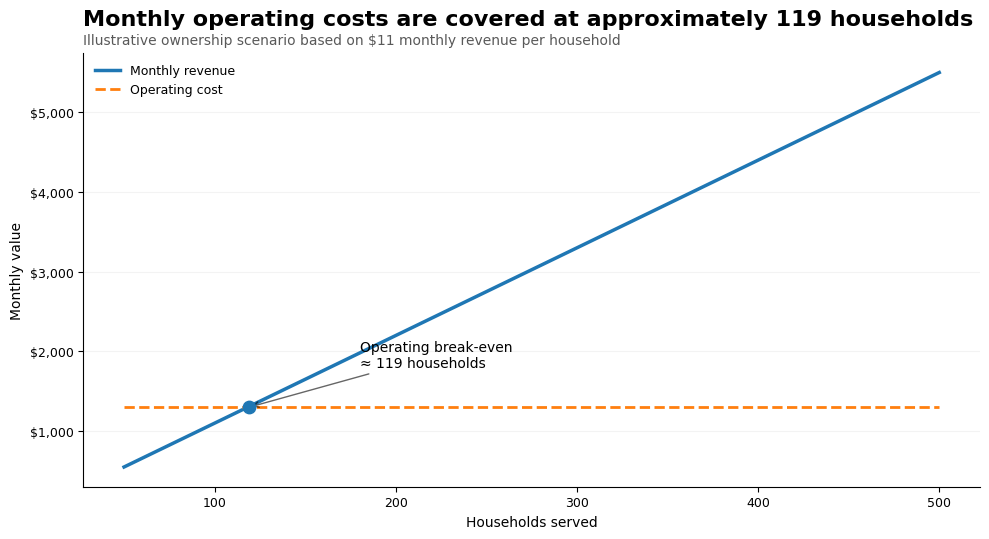

In [75]:
# ============================================================
# PLOT 2
# MONTHLY REVENUE VS OPERATING COST
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.plot(
    ownership_sens["households"],
    ownership_sens["monthly_revenue_usd"],
    linewidth=2.5,
    label="Monthly revenue"
)

ax.plot(
    ownership_sens["households"],
    ownership_sens["monthly_operating_cost_usd"],
    linewidth=2,
    linestyle="--",
    label="Operating cost"
)

# Break-even point
ax.scatter(
    119,
    1300,
    s=80,
    zorder=5
)

ax.annotate(
    "Operating break-even\n≈ 119 households",
    xy=(119, 1300),
    xytext=(180, 1800),
    arrowprops=dict(
        arrowstyle="->",
        alpha=0.6
    ),
    fontsize=10
)

ax.yaxis.set_major_formatter(
    FuncFormatter(
        lambda x, pos: f"${x:,.0f}"
    )
)

format_chart(
    ax,
    title="Monthly operating costs are covered at approximately 119 households",
    subtitle="Illustrative ownership scenario based on $11 monthly revenue per household",
    xlabel="Households served",
    ylabel="Monthly value"
)

ax.legend(
    frameon=False,
    fontsize=9
)

plt.tight_layout()
plt.show()

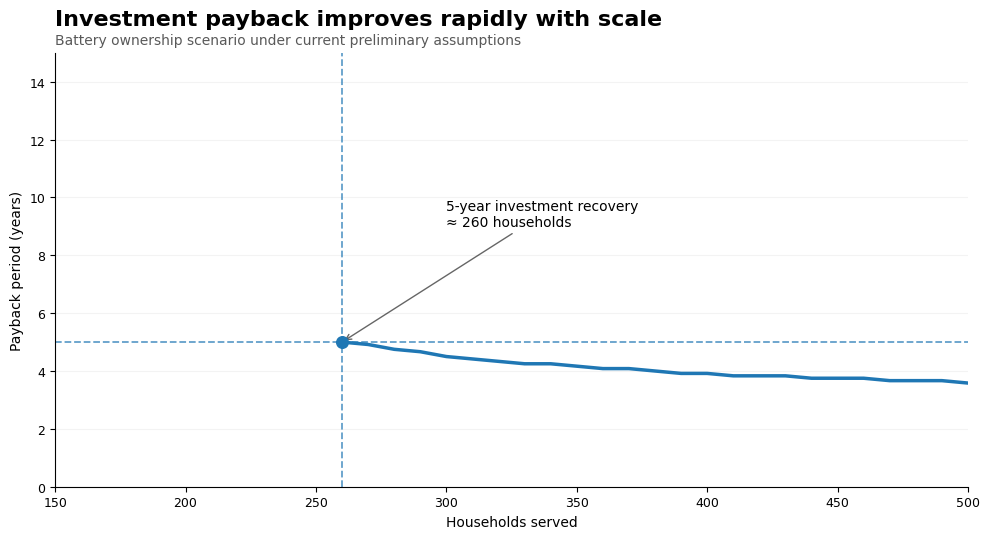

In [73]:
# ============================================================
# PLOT 3
# PAYBACK PERIOD
# How quickly does Magna recover its investment as the number of customers increases?
# ============================================================

fig, ax = plt.subplots(
    figsize=(10, 5.5)
)

ax.plot(
    payback_plot["households"],
    payback_plot["payback_years"],
    linewidth=2.5
)

# 5-year target
ax.axhline(
    5,
    linestyle="--",
    linewidth=1.3,
    alpha=0.7
)

# Investment recovery threshold
ax.axvline(
    260,
    linestyle="--",
    linewidth=1.3,
    alpha=0.7
)

# Highlight break-even point
ax.scatter(
    260,
    5,
    s=70,
    zorder=5
)

ax.annotate(
    "5-year investment recovery\n≈ 260 households",
    xy=(260, 5),
    xytext=(300, 9),
    arrowprops=dict(
        arrowstyle="->",
        alpha=0.6
    ),
    fontsize=10
)

# Focus on useful decision range
ax.set_xlim(
    150,
    500
)

ax.set_ylim(
    0,
    15
)

format_chart(
    ax,
    title="Investment payback improves rapidly with scale",
    subtitle="Battery ownership scenario under current preliminary assumptions",
    xlabel="Households served",
    ylabel="Payback period (years)"
)

plt.tight_layout()
plt.show()

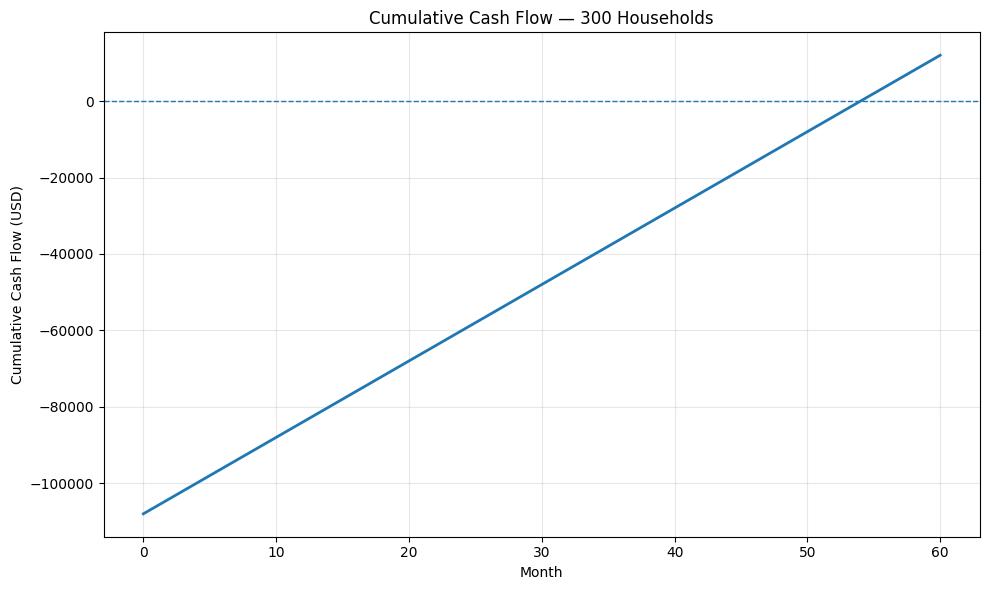

In [69]:
# ============================================================
# PLOT 4
# CUMULATIVE CASH FLOW
# The point at which this curve crosses zero is the investment recovery date.
# ============================================================

selected_households = 300


ownership_300 = simulate_ownership(
    inp,
    selected_households
)


plt.figure(
    figsize=(10, 6)
)


plt.plot(
    ownership_300[
        "month"
    ],

    ownership_300[
        "cumulative_cashflow_usd"
    ],

    linewidth=2
)


plt.axhline(
    0,
    linestyle="--",
    linewidth=1
)


plt.xlabel(
    "Month"
)

plt.ylabel(
    "Cumulative Cash Flow (USD)"
)

plt.title(
    f"Cumulative Cash Flow — "
    f"{selected_households} Households"
)

plt.grid(
    alpha=0.3
)

plt.tight_layout()

plt.show()

In [70]:
# ============================================================
# SCENARIO COMPARISON TABLE
# ============================================================

selected_households = 300


ownership_metrics_300 = (
    ownership_metrics(
        inp,
        selected_households
    )
)


ownership_5yr_rwf = (

    ownership_metrics_300[
        "five_year_net_cashflow_usd"
    ]

    * inp.usd_to_rwf

)


comparison_table = pd.DataFrame({

    "Scenario": [
        "Battery-as-a-Service",
        "Battery Ownership"
    ],

    "Business Model": [
        "$2/kWh/month storage fee",
        "$300 battery + $60 cookstove"
    ],

    "Asset Ownership": [
        "Supplier",
        "Magna"
    ]
})


display(
    comparison_table
)

,Scenario,Business Model,Asset Ownership
0,Battery-as-a-Service,$2/kWh/month storage fee,Supplier
1,Battery Ownership,$300 battery + $60 cookstove,Magna


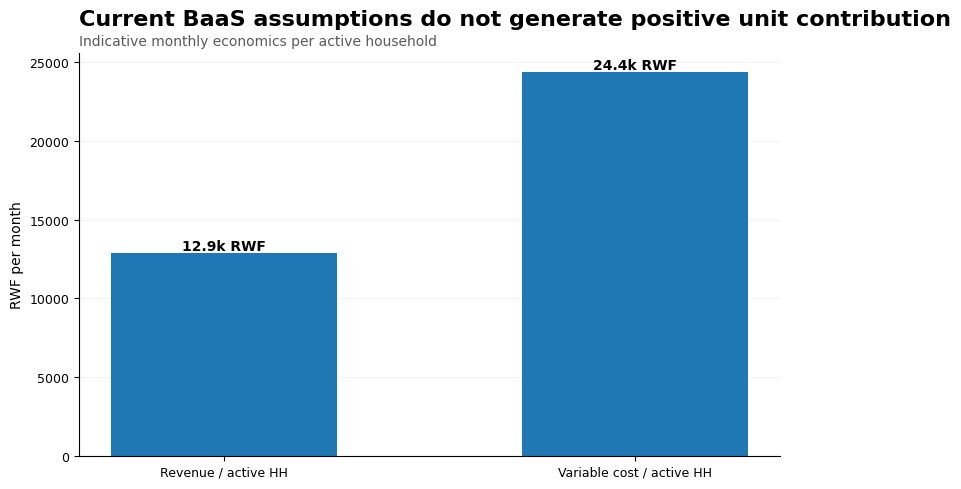

In [76]:
# ============================================================
# PLOT 5
# BaaS VS OWNERSHIP — 5-YEAR FINANCIAL COMPARISON
# ============================================================

revenue = 12900

electricity = 8000
baas = 13000 / 0.85
other_variable = (
    revenue * 0.02
    + 500
    + 300
)

total_variable_cost = (
    electricity
    + baas
    + other_variable
)

values = [
    revenue,
    total_variable_cost
]

labels = [
    "Revenue / active HH",
    "Variable cost / active HH"
]

fig, ax = plt.subplots(
    figsize=(8, 5)
)

bars = ax.bar(
    labels,
    values,
    width=0.55
)

for bar, value in zip(
    bars,
    values
):

    ax.text(
        bar.get_x()
        + bar.get_width()/2,

        value,

        f"{value/1000:.1f}k RWF",

        ha="center",
        va="bottom",
        fontsize=10,
        fontweight="bold"
    )

format_chart(
    ax,
    title="Current BaaS assumptions do not generate positive unit contribution",
    subtitle="Indicative monthly economics per active household",
    ylabel="RWF per month"
)

plt.tight_layout()
plt.show()

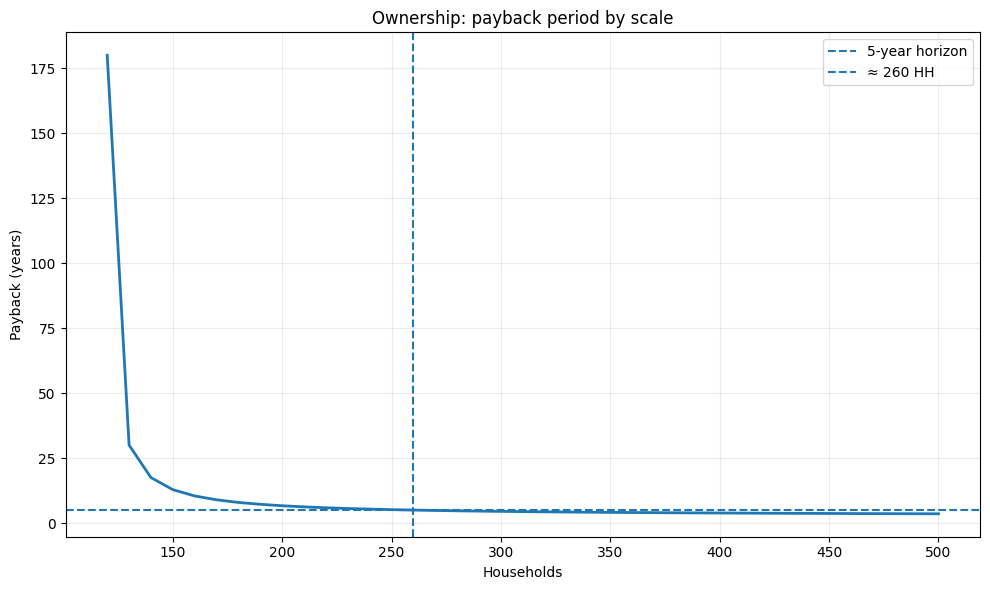

In [72]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================
# ASSUMPTIONS
# ==========================================

battery_cost_usd = 300
cookstove_cost_usd = 60
capex_per_household_usd = battery_cost_usd + cookstove_cost_usd

monthly_operation_cost_usd = 1300
monthly_charge_per_household_usd = 11

analysis_months = 60  # 5 years


# ==========================================
# PAYBACK CALCULATION BY HOUSEHOLD SCALE
# ==========================================

household_range = np.arange(120, 501, 10)

payback_years = []

for households in household_range:

    upfront_investment = (
        households
        * capex_per_household_usd
    )

    monthly_revenue = (
        households
        * monthly_charge_per_household_usd
    )

    monthly_net_cashflow = (
        monthly_revenue
        - monthly_operation_cost_usd
    )

    if monthly_net_cashflow > 0:

        payback_months = (
            upfront_investment
            / monthly_net_cashflow
        )

        payback_year = (
            payback_months / 12
        )

    else:

        payback_year = np.nan

    payback_years.append(
        payback_year
    )


# ==========================================
# 5-YEAR INVESTMENT RECOVERY BREAK-EVEN
# ==========================================

five_year_break_even_hh = np.ceil(
    monthly_operation_cost_usd
    /
    (
        monthly_charge_per_household_usd
        -
        (
            capex_per_household_usd
            / analysis_months
        )
    )
)


# ==========================================
# PLOT
# ==========================================

plt.figure(
    figsize=(10, 6)
)

plt.plot(
    household_range,
    payback_years,
    linewidth=2
)


# 5-year investment horizon
plt.axhline(
    y=5,
    linestyle="--",
    linewidth=1.5,
    label="5-year horizon"
)


# Household scale needed for 5-year recovery
plt.axvline(
    x=five_year_break_even_hh,
    linestyle="--",
    linewidth=1.5,
    label=f"≈ {int(five_year_break_even_hh)} HH"
)


plt.xlabel(
    "Households"
)

plt.ylabel(
    "Payback (years)"
)

plt.title(
    "Ownership: payback period by scale"
)

plt.legend()

plt.grid(
    alpha=0.25
)

plt.tight_layout()

plt.show()